# Домашнее задание к семинару 02 (HW02)

Тема: работа с табличными данными в Pandas, контроль качества данных, базовый EDA и визуализация в Matplotlib.

#### 1. Загрузка данных и первичный осмотр

1. Импортировать необходимые библиотеки:
   - `pandas` (обязательно),
   - при необходимости `numpy`,
   - `matplotlib.pyplot` для визуализации.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Загрузить учебный датасет в `pandas.DataFrame` с помощью `pd.read_csv` (или другого подходящего метода).

In [50]:
df = pd.read_csv('S02-hw-dataset.csv')

3. Вывести:
   - первые строки датасета (`head()`),
   - информацию о столбцах и типах (`info()`),
   - базовые описательные статистики (`describe()` или аналог).

In [51]:
df.head()

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [53]:
df.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


#### 2. Пропуски, дубликаты и базовый контроль качества

1. Посчитать долю пропусков в каждом столбце (например, через `isna().mean()` или аналог).

In [54]:
df.isna().mean()

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

2. Проверить наличие полностью дублирующих строк (через `duplicated()`).

In [55]:
df.duplicated().sum()

np.int64(1)

3. Найти и вывести «подозрительные» случаи, исходя из смысла датасета. Примеры:
   - отрицательные значения в полях, где их не должно быть (количество, цена и т.п.);
   - нереалистичные значения (например, возраст > 100, нулевой доход при ненулевых количествах и т.п.);
   - другие логические противоречия, характерные для конкретного датасета.

In [56]:
df[df["purchases"] < 0]

,user_id,age,country,purchases,revenue
5,6,120.0,FR,-1,785


In [57]:
df[df["revenue"] <= 0]

,user_id,age,country,purchases,revenue
6,7,46.0,RU,0,0
10,11,24.0,US,4,0
17,18,24.0,RU,0,0
33,34,28.0,FR,0,0


In [58]:
df[df["age"] < 0]

,user_id,age,country,purchases,revenue


In [59]:
df[df["age"] > 100]

,user_id,age,country,purchases,revenue
5,6,120.0,FR,-1,785


In [60]:
df[(df["revenue"] == 0) & (df["purchases"] > 0)]

,user_id,age,country,purchases,revenue
10,11,24.0,US,4,0


4. Кратко (1-2 абзаца) описать текстом, какие проблемы качества данных были обнаружены.

В ходе проверки качества данных в учебном датасете были выявлены несколько существенных проблем:
1. Присутствуют нереалистичные и некорректные значения, такие как возраст пользователя 120 лет, что превышает биологически возможные пределы, а также отрицательное количество покупок, что невозможно по смыслу. Эти ошибки указывают на неверный ввод данных или нарушения при их сборе.
2. Обнаружены логические противоречия: например, случаи, когда пользователь имеет ненулевое количество покупок при нулевой выручке, что не согласуется с типичным поведением транзакций. 
3. Наряду с этим выявлены дубликаты записей.

#### 3. Базовый EDA: группировки, агрегаты и частоты


1. Посчитать частоты для одной или двух категориальных переменных (например, `value_counts()` для столбца с категорией/страной/классом).

In [61]:
country_counts = df["country"].value_counts()
print("Частоты по странам:")
print(country_counts)

Частоты по странам:
country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64


2. Выполнить хотя бы одну осмысленную группировку с агрегатами через `groupby`:
   - например, среднее и сумму по количественным признакам в разрезе категорий.


In [62]:
group_stats = (
    df.groupby("country")
      .agg(
          n_users=("user_id", "count"),
          mean_age=("age", "mean"),
          mean_purchases=("purchases", "mean"),
          total_revenue=("revenue", "sum"),
          mean_revenue=("revenue", "mean")
      )
)

print("\nГруппировка по странам:")
print(group_stats)


Группировка по странам:
         n_users   mean_age  mean_purchases  total_revenue  mean_revenue
country                                                                 
CN             2  24.000000        4.500000           2108   1054.000000
DE             6  34.600000        6.500000           8673   1445.500000
FR            12  46.250000        4.250000           8111    675.916667
RU            13  30.076923        4.769231          10271    790.076923
US             8  36.714286        4.625000           4459    557.375000


3. При необходимости ввести дополнительные «коридоры» (bins) или группировки (например, возрастные группы, диапазоны значений и т.п.).


In [63]:
bins = [0, 24, 34, 44, 200]
labels = ["≤24", "25–34", "35–44", "45+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

age_group_stats = (
    df.groupby("age_group")
      .agg(
          n=("user_id", "count"),
          mean_purchases=("purchases", "mean"),
          mean_revenue=("revenue", "mean")
      )
)

print("\nСтатистики по возрастным группам:")
print(age_group_stats)


Статистики по возрастным группам:
            n  mean_purchases  mean_revenue
age_group                                  
≤24        11        5.000000    696.272727
25–34      10        5.300000   1009.600000
35–44       7        5.000000   1042.857143
45+        11        3.636364    603.727273


/var/folders/k8/p2vxh73s1qj6d4fytf078ghh0000gn/T/ipykernel_36746/2514440624.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")


4. Кратко (1-2 абзаца) описать текстом основные наблюдения:
   - какие категории доминируют,
   - как отличаются группы по средним значениям,
   - есть ли неожиданные эффекты.

Распределение пользователей по странам оказалось неравномерным: наиболее представленные категории: Россия и Франция, тогда как США, Германия и Китай встречаются реже. По агрегированным статистикам видно, что среднее число покупок и средняя выручка заметно различаются между странами, что может отражать различия в платёжеспособности, активности или составе выборки.

Анализ возрастных групп показал, что основная часть пользователей относится к диапазону 25–34 и 35–44 лет. Пользователи среднего возраста в среднем демонстрируют более высокую выручку и количество покупок, тогда как самые младшие и самые старшие группы дают меньше транзакционной активности. Это соответствует типичной модели поведения, где платежеспособность и активность наиболее высоки у взрослых пользователей среднего возраста.

### 4. Визуализация данных в Matplotlib


1. **Одну гистограмму** для количественного признака:
   - осмысленный выбор числа корзин (`bins`),
   - подписи осей и заголовок.


In [72]:
import os

os.makedirs("figures", exist_ok=True)

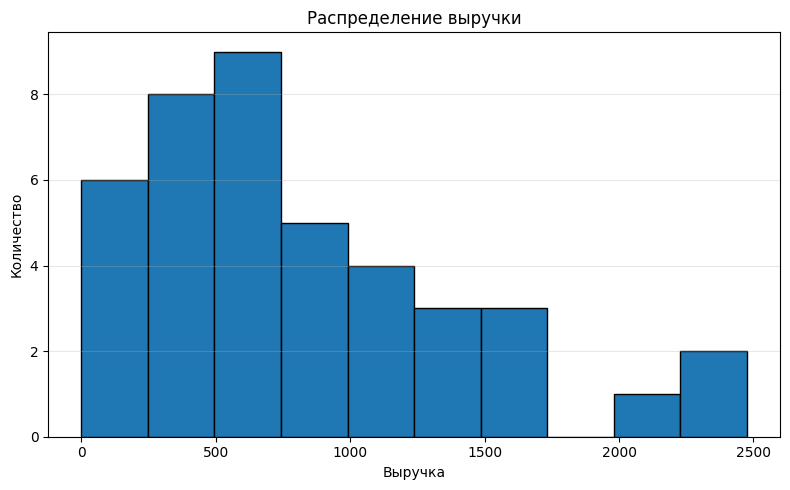

In [73]:
plt.figure(figsize=(8, 5))
plt.hist(df["revenue"], bins=10, edgecolor="black")
plt.xlabel("Выручка")
plt.ylabel("Количество")
plt.title("Распределение выручки")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/hist.png", dpi=300)
plt.show()

2. **Один боксплот (boxplot)** для количественного признака:
   - можно как общий, так и по группам (например, по категориям),
   - подписи оси и заголовок.


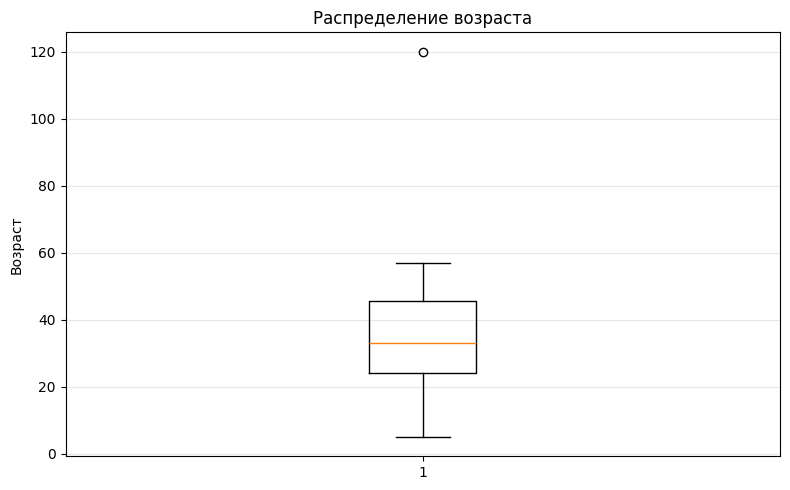

In [76]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["age"].dropna())
plt.ylabel("Возраст")
plt.title("Распределение возраста")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/boxplot.png", dpi=300)
plt.show()

3. **Один scatter plot** (диаграмма рассеяния) для пары количественных признаков:
   - подписи обеих осей,
   - заголовок,
   - при желании можно добавить цвет/легенду для различения категорий.


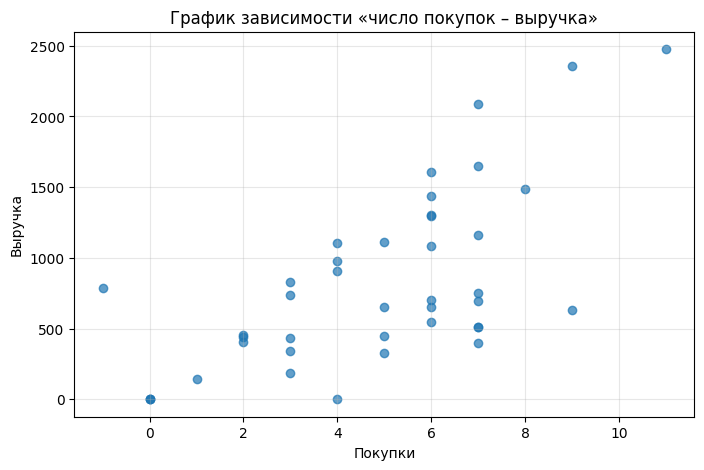

In [77]:
plt.figure(figsize=(8, 5))
plt.scatter(df["purchases"], df["revenue"], alpha=0.7)
plt.xlabel("Покупки")
plt.ylabel("Выручка")
plt.title("График зависимости «число покупок – выручка»")
plt.grid(True, alpha=0.3)

plt.savefig("figures/scatter_plot.png", dpi=300)
plt.show()


4. Сохранить **минимум один** из построенных графиков в папку `homeworks/HW02/figures/`:
   - использовать `plt.savefig(...)` или аналог;
   - убедиться, что файл действительно появляется в репозитории и может быть открыт отдельно от ноутбука.